In [29]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from itertools import combinations

In [ ]:
#get vscode auto-completion to work and fill in the file paths for the csv files quick and easily
csv_files = ['C:\\Users\\spray\\OneDrive\\Documents\\GitHub\\PCI-Group-21\\examples\\testing_0.csv', 'C:\\Users\\spray\\OneDrive\\Documents\\GitHub\\PCI-Group-21\\examples\\testing_0.5.csv', 'C:\\Users\\spray\\OneDrive\\Documents\\GitHub\\PCI-Group-21\\examples\\testing_1.csv', 'C:\\Users\\spray\\OneDrive\\Documents\\GitHub\\PCI-Group-21\\examples\\testing_1.5.csv', 'C:\\Users\\spray\\OneDrive\\Documents\\GitHub\\PCI-Group-21\\examples\\testing_2.csv'] 
df1 = pd.DataFrame()
for csv in csv_files:
    df = pd.read_csv(csv)
    df['attraction_magnitude'] = float(csv.split('_')[1].replace('.csv', ''))
    df1 = pd.concat([df1, df], ignore_index=True)

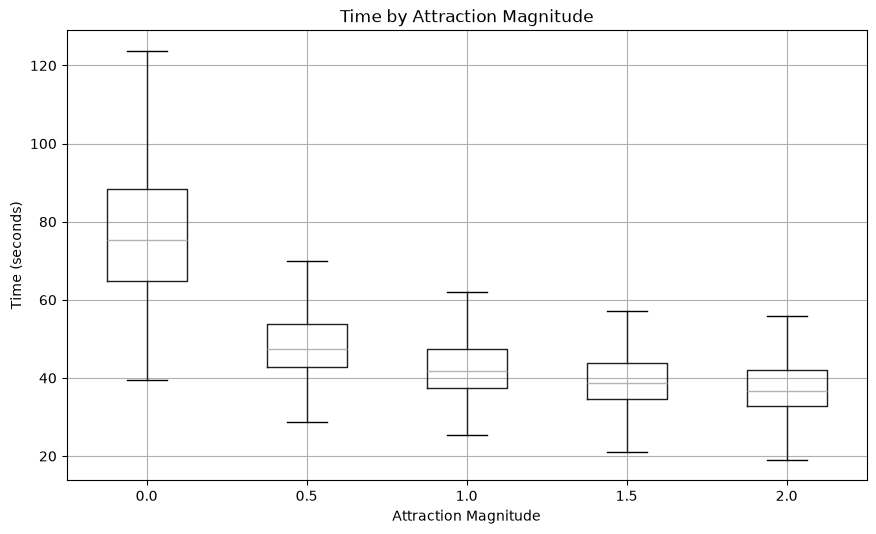

In [23]:
df1['end_time'] = df1['end_ticks'] / 60  # Convert ticks to seconds
df1.boxplot(column='end_time', by='attraction_magnitude', figsize=(10, 6), showfliers=False)

plt.title('Time by Attraction Magnitude')
plt.suptitle('')
plt.xlabel('Attraction Magnitude')
plt.ylabel('Time (seconds)')
plt.show()

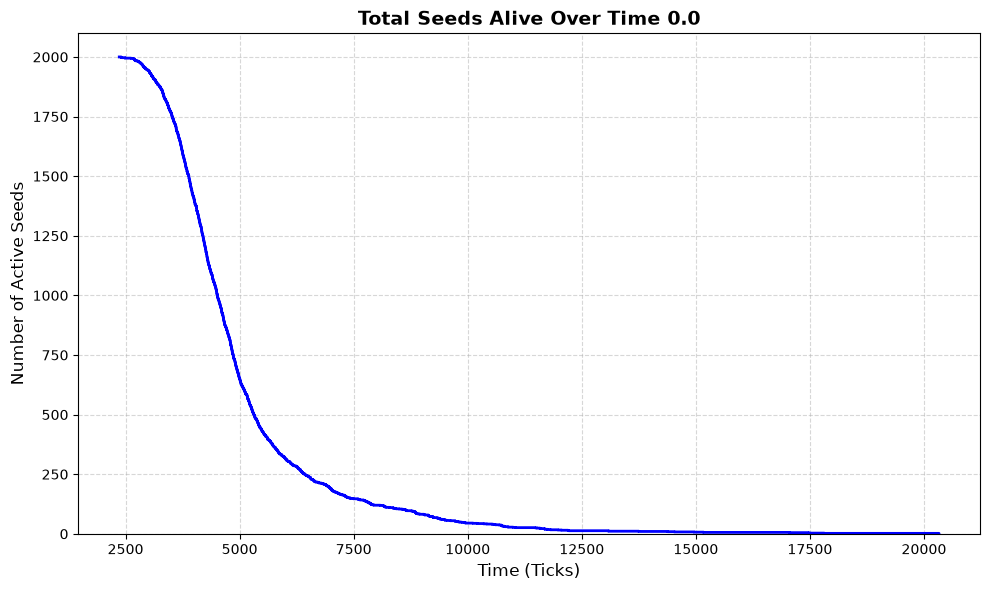

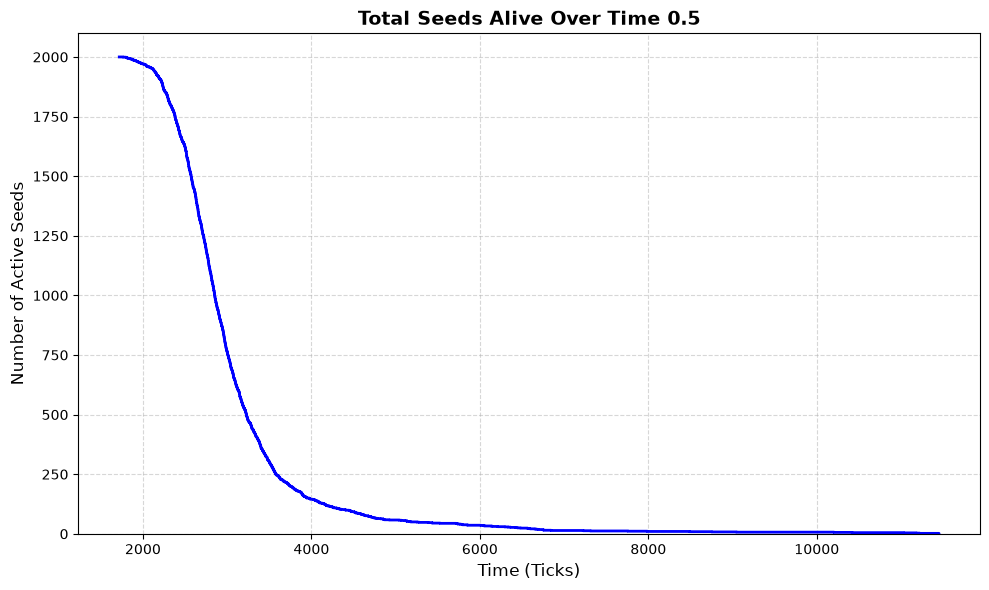

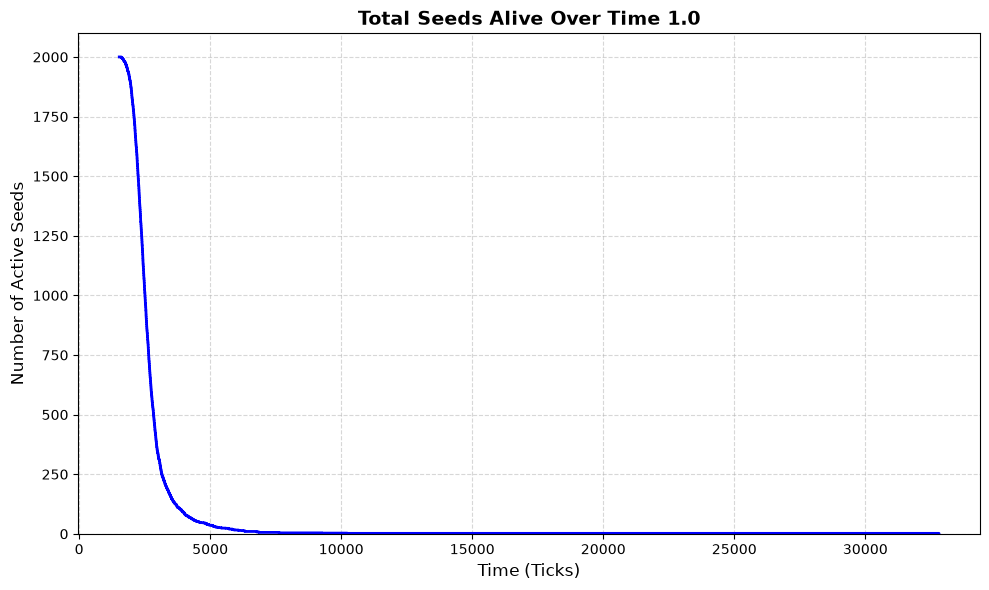

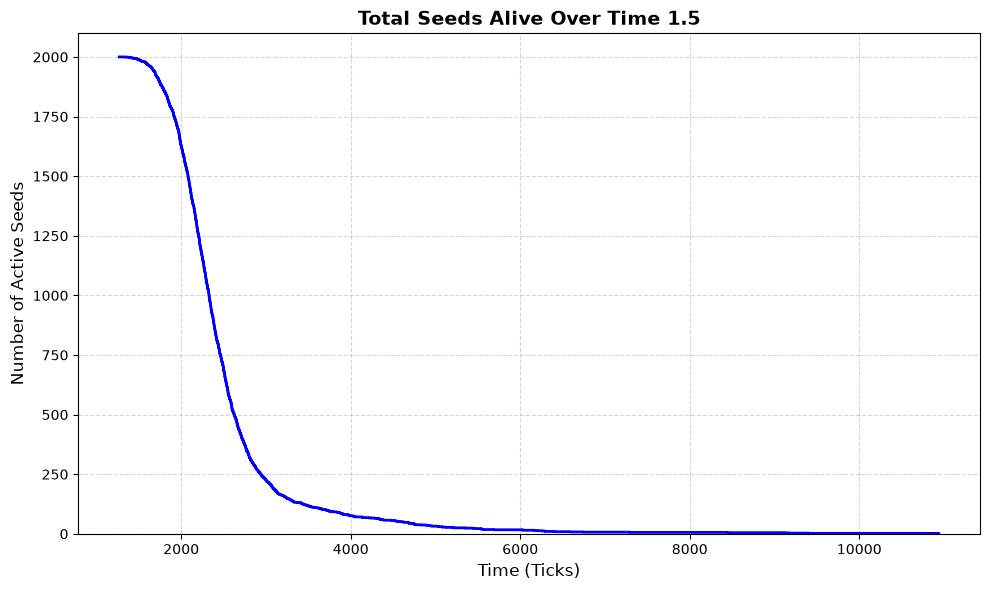

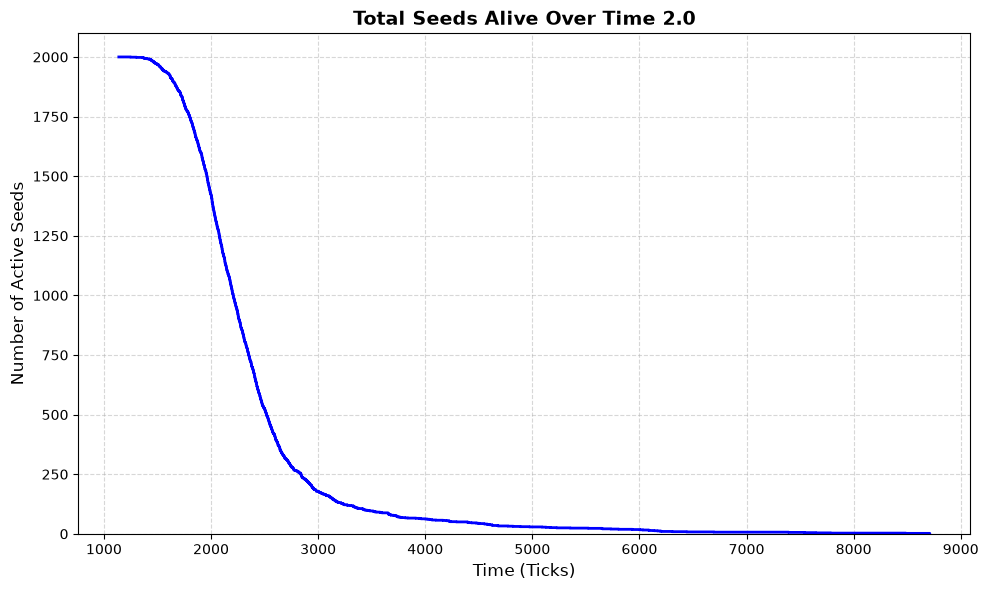

In [17]:
csv_files = ['C:\\Users\\spray\\OneDrive\\Documents\\GitHub\\PCI-Group-21\\examples\\testing_0.csv', 'C:\\Users\\spray\\OneDrive\\Documents\\GitHub\\PCI-Group-21\\examples\\testing_0.5.csv', 'C:\\Users\\spray\\OneDrive\\Documents\\GitHub\\PCI-Group-21\\examples\\testing_1.csv', 'C:\\Users\\spray\\OneDrive\\Documents\\GitHub\\PCI-Group-21\\examples\\testing_1.5.csv', 'C:\\Users\\spray\\OneDrive\\Documents\\GitHub\\PCI-Group-21\\examples\\testing_2.csv'] 

for csv in csv_files:
    df = pd.read_csv(csv)
    df['attraction_magnitude'] = float(csv.split('_')[1].replace('.csv', ''))
    end_ticks = df['end_ticks']
    total_seeds = len(end_ticks)
    sorted_ticks = end_ticks.sort_values().reset_index(drop=True)
    seeds_alive = total_seeds - sorted_ticks.index

    plt.figure(figsize=(10, 6))
    plt.step(sorted_ticks, seeds_alive, where='post', color='blue', linewidth=2)

    plt.title(f'Total Seeds Alive Over Time {df["attraction_magnitude"].iloc[0]}', fontsize=14, fontweight='bold')
    plt.xlabel('Time (Ticks)', fontsize=12)
    plt.ylabel('Number of Active Seeds', fontsize=12)
    plt.ylim(0, total_seeds + (total_seeds * 0.05))
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

In [35]:
rng = np.random.default_rng()

# end_ticks to dictionary for t-tests
data_dict = {}
for csv in csv_files:
    df = pd.read_csv(csv)
    magnitude = float(csv.split('_')[1].replace('.csv', ''))
    data_dict[magnitude] = df['end_ticks'].values #one more array can't hurt, right? right?

# Welch's t-test
results = []
for attraction1, attraction2 in combinations(sorted(data_dict.keys()), 2):
    t_stat, p_value = stats.ttest_ind(
        data_dict[attraction1], #this is a numpy list of every end_tick for the given attraction magnitude
        data_dict[attraction2],
        equal_var=False #will run Weldh's t-test, instead of Student's t-test, supposedly this is better, whose to say
    )
    results.append({
        'attr_magnitude_1': attraction1,
        'attr_magnitude_2': attraction2,
        't_statistic': t_stat,
        'p_value': p_value,
        'significant (p<0.05)': p_value < 0.05
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

 attr_magnitude_1  attr_magnitude_2  t_statistic       p_value  significant (p<0.05)
              0.0               0.5    42.961491  0.000000e+00                  True
              0.0               1.0    49.948623  0.000000e+00                  True
              0.0               1.5    57.208317  0.000000e+00                  True
              0.0               2.0    60.538926  0.000000e+00                  True
              0.5               1.0    12.388096  1.322400e-34                  True
              0.5               1.5    21.904766 2.085105e-100                  True
              0.5               2.0    27.316071 2.787880e-150                  True
              1.0               1.5     7.242839  5.309998e-13                  True
              1.0               2.0    11.990832  1.610316e-32                  True
              1.5               2.0     5.422603  6.221730e-08                  True
